In [1]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt

def plot_image(img, figsize_in_inches=(10, 10)):
    fig, ax = plt.subplots(figsize=figsize_in_inches)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()
    
def plot_images(imgs, figsize_in_inches=(10, 10)):
    fig, axs = plt.subplots(1, len(imgs), figsize=figsize_in_inches)
    for col, img in enumerate(imgs):
        axs[col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

In [3]:
def annotate_tile_images(source_folder, target_folder, is_draw_hori=False, divide_in_three=True, line_width=100):
    for index in range(0, 6):
        image_file = f'Tile_1_1_{index}.jpg'
        image_bgr = cv2.imread(os.path.join(source_folder, image_file))
        image_size = image_bgr.shape[:2][::-1]
        start_x, end_x = line_width // 2, 5060
        if index == 0:
            image_bgr = cv2.line(image_bgr, (start_x, 0,), (start_x, image_size[1]), (255, 0, 0,), line_width, lineType=cv2.LINE_AA)
        elif index == 5:
            image_bgr = cv2.line(image_bgr, (end_x, 0,), (end_x, image_size[1]), (255, 0, 0,), line_width, lineType=cv2.LINE_AA)
        
        if is_draw_hori:
            top_line_y = 100
            bottom_line_y = image_size[1] - 100
            origin_y = [27257, 27088, 26933, 26744, 26559, 26369]
            # origin_y = [28029, 27859, 27691, 27501, 27322, 27136]
            # draw top line
            offset_y = origin_y[index] - min(origin_y)
            image_bgr = cv2.line(image_bgr, (start_x, top_line_y + offset_y,), (image_size[0], top_line_y + offset_y), (255, 0, 0,), line_width, lineType=cv2.LINE_AA)
            # draw bottom line
            offset_y = origin_y[index] - max(origin_y)
            image_bgr = cv2.line(image_bgr, (start_x, bottom_line_y + offset_y,), (image_size[0], bottom_line_y + offset_y), (255, 0, 0,), line_width, lineType=cv2.LINE_AA)            
        
        if divide_in_three:
            height = image_size[1]
            image_0 = image_bgr[0:int(height*0.5), :, :]
            image_1 = image_bgr[int(height*0.25):int(height*0.75), :, :]
            image_2 = image_bgr[int(height*0.5):, :, :]
            cv2.imwrite(os.path.join(target_folder, f'Tile_1_1_{index}_0.jpg'), image_0)
            cv2.imwrite(os.path.join(target_folder, f'Tile_1_1_{index}_1.jpg'), image_1)
            cv2.imwrite(os.path.join(target_folder, f'Tile_1_1_{index}_2.jpg'), image_2) 
        else:
            cv2.imwrite(os.path.join(target_folder, image_file), image_bgr)
        
source_folder = '/home/qcr/cgras_data/detector/Tile_1_1/'
target_folder = '/home/qcr/cgras_data/detector/AnnotatedTile_1_1/'
annotate_tile_images(source_folder, target_folder)

(5304, 7952)


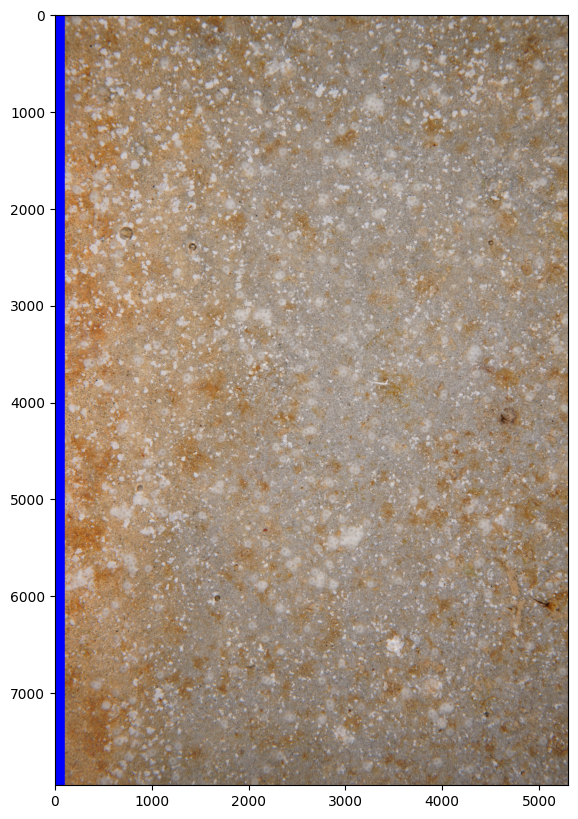

True

In [3]:
image_file = '/home/qcr/cgras_data/detector/Tile_1_1/Tile_1_1_0.jpg'

image_bgr = cv2.imread(image_file)
image_size = image_bgr.shape[:2][::-1]
print(image_size)
line_width = 100
image_bgr = cv2.line(image_bgr, (line_width // 2, 0,), (line_width // 2, image_size[1]), (255, 0, 0,), line_width, lineType=cv2.LINE_AA)

plot_image(image_bgr)

out_image_file = '/home/qcr/cgras_data/detector/AnnotatedTile_1_1/Tile_1_1_0.jpg'
cv2.imwrite(out_image_file, image_bgr)
